   Jumlah mahasiswa : 300
   Jumlah kolom     : 7


,Education_Level,CGPA,Family_Support,Social_Media_Hours,Financial_Status,Exam_Approach,Lecturer_Mentor_Role
0,University Student (Mahasiswa/Mahasiswi),3.51 - 4.00,5,High / Tinggi (5 - 8 Hours),Middle Class (Sufficient resources / Cukup & t...,Flexible: Subject to current mood and motivati...,4
1,University Student (Mahasiswa/Mahasiswi),3.01 - 3.50,4,Moderate / Sedang (2 - 5 Hours),Middle Class (Sufficient resources / Cukup & t...,Flexible: Subject to current mood and motivati...,3
2,University Student (Mahasiswa/Mahasiswi),3.51 - 4.00,5,Low / Rendah (< 2 Hours),Upper Class (Abundant resources / Sangat memadai),Structured: Planned and executed well in advan...,5
3,University Student (Mahasiswa/Mahasiswi),3.51 - 4.00,5,High / Tinggi (5 - 8 Hours),Upper Class (Abundant resources / Sangat memadai),Flexible: Subject to current mood and motivati...,2
4,University Student (Mahasiswa/Mahasiswi),3.51 - 4.00,5,Moderate / Sedang (2 - 5 Hours),Upper Class (Abundant resources / Sangat memadai),Structured: Planned and executed well in advan...,4



Missing Values:
Education_Level         0
CGPA                    0
Family_Support          0
Social_Media_Hours      0
Financial_Status        0
Exam_Approach           0
Lecturer_Mentor_Role    0
dtype: int64
Label Encoding


,Education_Level,CGPA,Family_Support,Social_Media_Hours,Financial_Status,Exam_Approach,Lecturer_Mentor_Role
0,0,2,5,1,1,0,4
1,0,1,4,3,1,0,3
2,0,2,5,2,2,2,5
3,0,2,5,1,2,0,2
4,0,2,5,3,2,2,4


   Variable : ['CGPA', 'Family_Support', 'Social_Media_Hours', 'Financial_Status', 'Exam_Approach', 'Lecturer_Mentor_Role']
   Shape data         : (300, 6)


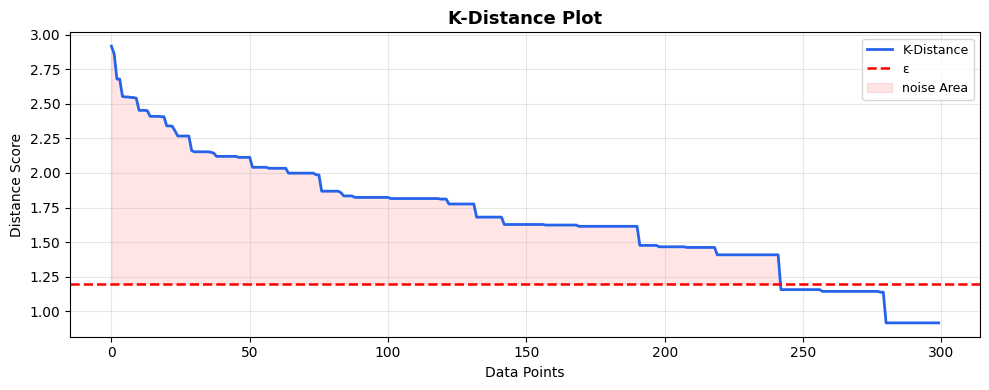

   ε (epsilon) = 1.2
   MinPts      = 12
DBSCAN Results
  Total Clusters   : 4
  Noise Points     : 195 Students
  Core Points      : 52 Students
  Silhouette Score : 0.2350 

  Details per Cluster:
    Label  -1 :  195 students  ← noise / outlier
    Label   0 :   55 students  
    Label   1 :   23 students  
    Label   2 :   23 students  
    Label   3 :    4 students  


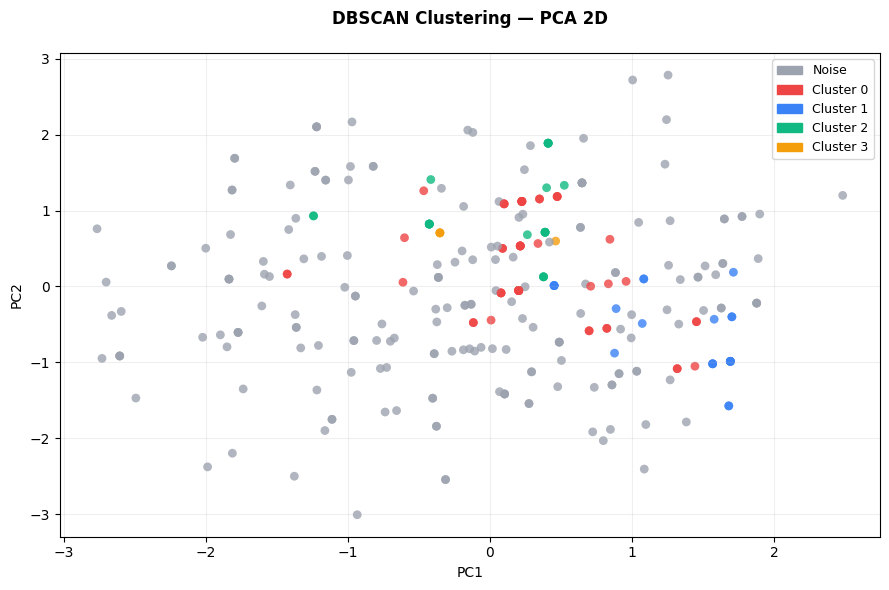

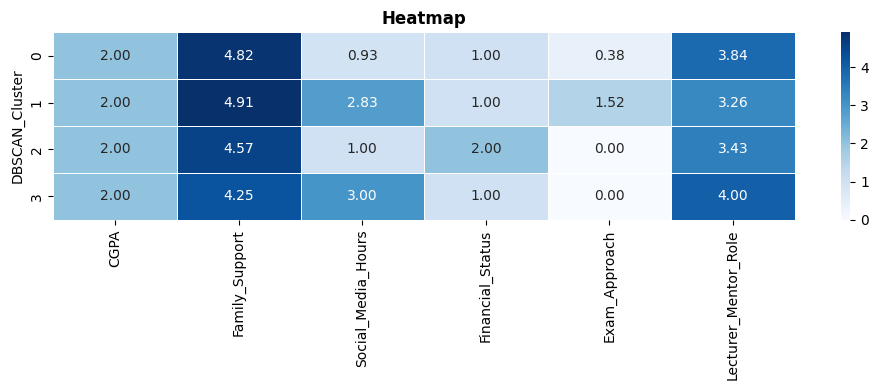

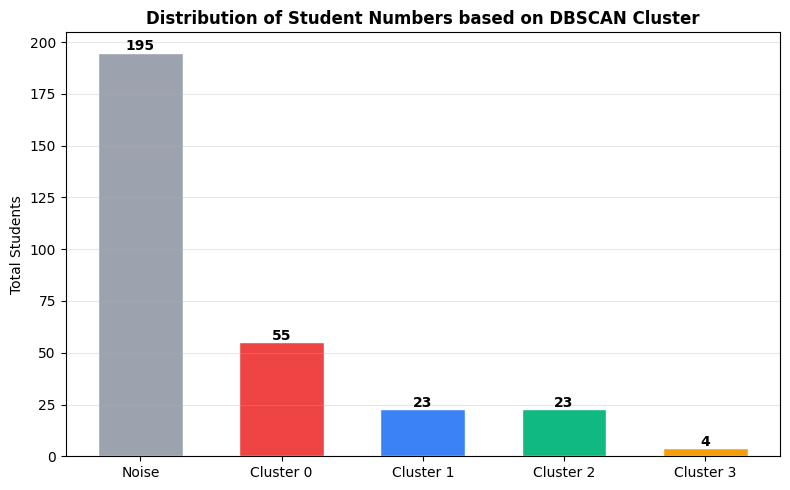

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

df = pd.read_csv('data_univstudent_300_final.csv')

df.columns = [
    "Education_Level",
    "CGPA",
    "Family_Support",
    "Social_Media_Hours",
    "Financial_Status",
    "Exam_Approach",
    "Lecturer_Mentor_Role"
]

print(f"   Jumlah mahasiswa : {df.shape[0]}")
print(f"   Jumlah kolom     : {df.shape[1]}")
display(df.head())

print(f"\nMissing Values:")
print(df.isnull().sum())


df_enc = df.copy()

kolom_kategori = [
    "Education_Level",
    "CGPA",
    "Social_Media_Hours",
    "Financial_Status",
    "Exam_Approach"
]

le = LabelEncoder()
for col in kolom_kategori:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))
print("Label Encoding")
display(df_enc.head())
features = [
    "CGPA",
    "Family_Support",
    "Social_Media_Hours",
    "Financial_Status",
    "Exam_Approach",
    "Lecturer_Mentor_Role"
]
X = df_enc[features].values
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"   Variable : {features}")
print(f"   Shape data         : {X_scaled.shape}")



MinPts  = 12
k       = MinPts - 1
nbrs        = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances  = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color="#2563EB", linewidth=2, label="K-Distance")
plt.axhline(y=1.2, color="red", linestyle="--", linewidth=1.8,
            label="ε")
plt.fill_between(range(len(k_distances)), k_distances, 1.2,
                 where=(k_distances >= 1.2), alpha=0.1, color="red",
                 label="noise Area")
plt.title(f"K-Distance Plot",
          fontsize=13, fontweight="bold")
plt.xlabel("Data Points")
plt.ylabel(f"Distance Score")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
epsilon = 1.2 # Defining epsilon based on the plot's red line
print(f"   ε (epsilon) = {epsilon}")
print(f"   MinPts      = {MinPts}")


dbscan        = DBSCAN(eps=epsilon, min_samples=MinPts, metric="euclidean")
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise    = list(dbscan_labels).count(-1)
n_core     = len(dbscan.core_sample_indices_)

print("DBSCAN Results")
print(f"  Total Clusters   : {n_clusters}")
print(f"  Noise Points     : {n_noise} Students")
print(f"  Core Points      : {n_core} Students")
if n_clusters > 1:
    mask = dbscan_labels != -1
    sil  = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f"  Silhouette Score : {sil:.4f} ")
print("\n  Details per Cluster:")
for lbl, cnt in pd.Series(dbscan_labels).value_counts().sort_index().items():
    ket = "← noise / outlier" if lbl == -1 else ""
    print(f"    Label {lbl:3d} : {cnt:4d} students  {ket}")

PALETTE = ["#EF4444", "#3B82F6", "#10B981", "#F59E0B",
           "#8B5CF6", "#EC4899", "#14B8A6", "#F97316"]

def warna_label(labels):
    return ["#9CA3AF" if l == -1 else PALETTE[l % len(PALETTE)]
            for l in labels]
# PCA → reduksi ke 2D supaya bisa digambar
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev    = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(9, 6))
colors = warna_label(dbscan_labels)
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors,
           s=40, alpha=0.80, edgecolors="none")

ax.set_title(f"DBSCAN Clustering — PCA 2D\n",
             fontsize=12, fontweight="bold")
ax.set_xlabel(f"PC1")
ax.set_ylabel(f"PC2")
ax.grid(alpha=0.2)

unique_lbl = sorted(set(dbscan_labels))
handles = [mpatches.Patch(
               color="#9CA3AF" if l == -1 else PALETTE[l % len(PALETTE)],
               label="Noise" if l == -1 else f"Cluster {l}")
           for l in unique_lbl]
ax.legend(handles=handles, fontsize=9, loc="best")

plt.tight_layout()
plt.show()


df_result  = df_enc[features].copy()
df_result["DBSCAN_Cluster"] = dbscan_labels

df_no_noise = df_result[df_result["DBSCAN_Cluster"] != -1]
profil      = df_no_noise.groupby("DBSCAN_Cluster")[features].mean()

plt.figure(figsize=(10, 4))
sns.heatmap(profil, annot=True, fmt=".2f", cmap="Blues",
            linewidths=0.5, cbar=True)
plt.title("Heatmap",
          fontsize=12, fontweight="bold")
plt.xlabel("")
plt.tight_layout()
plt.show()

counts  = pd.Series(dbscan_labels).value_counts().sort_index()
xlabels = ["Noise" if l == -1 else f"Cluster {l}" for l in counts.index]
colors  = ["#9CA3AF" if l == -1 else PALETTE[l % len(PALETTE)]
            for l in counts.index]

plt.figure(figsize=(8, 5))
bars = plt.bar(xlabels, counts.values, color=colors,
               edgecolor="white", width=0.6)
plt.title("Distribution of Student Numbers based on DBSCAN Cluster",
          fontsize=12, fontweight="bold")
plt.ylabel("Total Students")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1,
             str(val), ha="center", fontsize=10, fontweight="bold")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()